In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [4]:
box_img = cv.imread('../../../class.vision/images/box.png')
box_in_scene_img = cv.imread('../../../class.vision/images/box_in_scene.png')
blox_img = cv.imread('../../../class.vision/images/blox.jpg')

Text(0.5, 1.0, 'Rich')

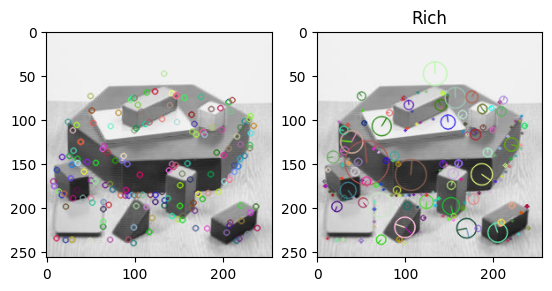

In [12]:
draw_img1 = blox_img.copy()
draw_img2 = blox_img.copy()
sift = cv.SIFT_create()
keypoints = sift.detect(blox_img, None)
cv.drawKeypoints(draw_img1,keypoints, draw_img1)
cv.drawKeypoints(draw_img2,keypoints, draw_img2, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.subplot(121); plt.imshow(draw_img1[...,::-1]); plt.title("")
plt.subplot(122); plt.imshow(draw_img2[...,::-1]); plt.title("Rich")

Text(0.5, 1.0, '')

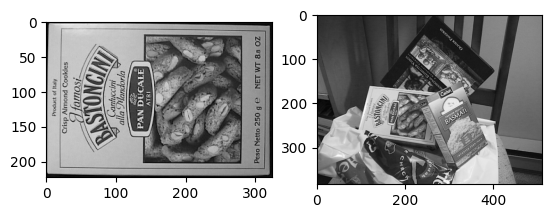

In [13]:
plt.subplot(121); plt.imshow(box_img[...,::-1]); plt.title("")
plt.subplot(122); plt.imshow(box_in_scene_img[...,::-1]); plt.title("")

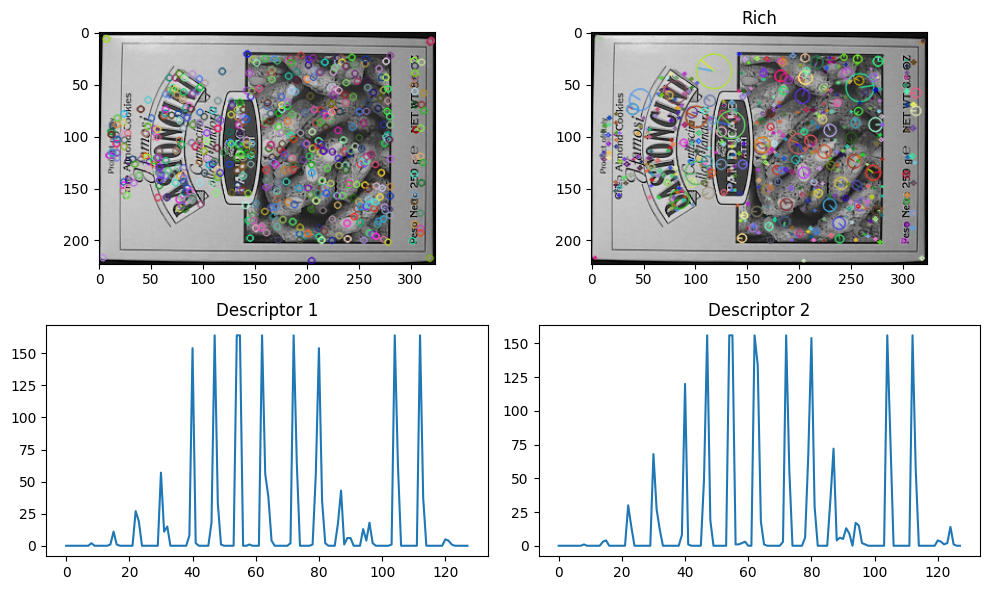

In [49]:
draw_img1 = box_img.copy()
draw_img2 = box_img.copy()
keypoints1, des1 = sift.detectAndCompute(box_img, None)
keypoints2, des2 = sift.detectAndCompute(box_in_scene_img, None)
cv.drawKeypoints(draw_img1,keypoints, draw_img1)
cv.drawKeypoints(draw_img2,keypoints, draw_img2, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(10,6))
plt.subplot(221); plt.imshow(draw_img1[...,::-1]); plt.title("")
plt.subplot(222); plt.imshow(draw_img2[...,::-1]); plt.title("Rich")
plt.subplot(223); plt.plot(des1[0]); plt.title("Descriptor 1")
plt.subplot(224); plt.plot(des1[1]); plt.title("Descriptor 2")
plt.tight_layout()


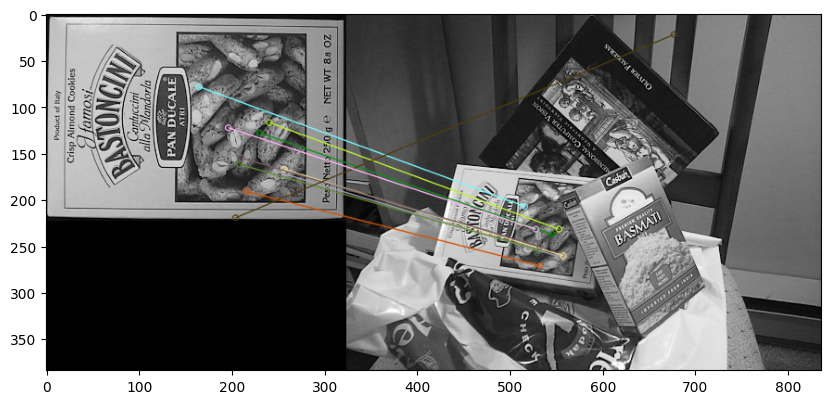

In [44]:
bf = cv.BFMatcher(cv.NORM_L1, crossCheck=False)

matches = bf.match(des1, des2)

matches = sorted(matches, key = lambda x:x.distance)

img3 = cv.drawMatches(box_img, keypoints1, box_in_scene_img, keypoints2, matches[:10], None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(10,6))
plt.imshow(img3);